In [1]:
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as utils;
import pandas as pd;
import os;
import glob;

# Styling.
plt.style.use("ggplot");

In [ ]:
# Test inputs - delete when done!
BASE_PATH = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_7.0"
PREFIX = "DN_DAYCASE_DELTASCAN_255X512_Q3.5"
radial_index = 180;

df = utils.parameter_scan_analysis_phi2D(BASE_PATH, PREFIX, radial_index);

if df is not None:
	print(df)

Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.1 with parameter value: -0.1
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.2 with parameter value: -0.2
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3 with parameter value: -0.3
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_0.0 with parameter value: 0.0
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_0.1 with parameter value: 0.1
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_0.2 with parameter value: 0.2
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_0.3 with parameter value: 0.3
   parameter_value  gam_frequency  gam_growth_rate  \
2             -0.3    2318.378105    -17817.908592   
1             -0.2    2310.300132    -16461.064935   
0             -0.1    2318.378105    -19433.208806   
3              0.0    2326.456077    -17280.577599   
4              0.1    2334.534050    -15989.388566   
5              0.2    2350.689994    -19677.429163   
6              0.3    2374.923912    -15016.744129   

                              folder

<>:20: SyntaxWarning: invalid escape sequence '\g'
<>:33: SyntaxWarning: invalid escape sequence '\k'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\g'
<>:33: SyntaxWarning: invalid escape sequence '\k'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_113425/315172026.py:20: SyntaxWarning: invalid escape sequence '\g'
  ax2.set_ylabel('$-\gamma [ms^{-1}]$', color=color_damp, fontsize=12)
/tmp/ipykernel_113425/315172026.py:33: SyntaxWarning: invalid escape sequence '\k'
  plt.title(f'GAM characteristics vs. {param_label}, $q = 3.5$, $\kappa = 1.0$, radial index = {radial_index}/255',
/tmp/ipykernel_113425/315172026.py:39: SyntaxWarning: invalid escape sequence '\d'
  plot_parameter_scan_results(df, param_label=f"$\delta$");


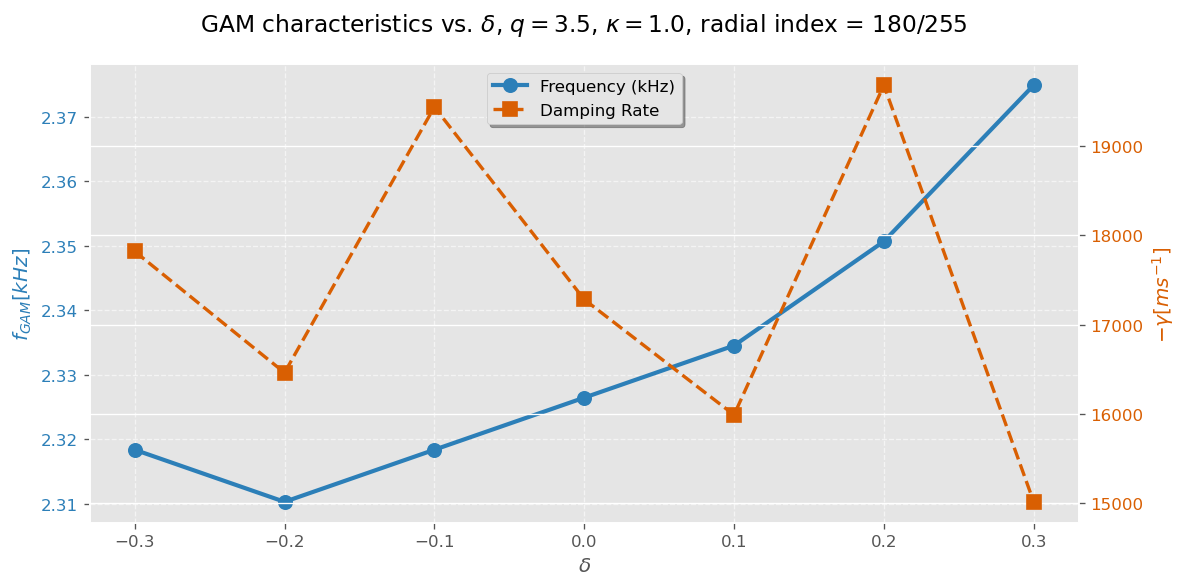

In [ ]:
def plot_parameter_scan_results(df, param_label):
	# TODO: AI nonsense. Replace asap, please...
	fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

	# --- Axis 1: GAM Frequency ---
	color_freq = '#2c7fb8' # Deep Blue
	ax1.set_xlabel(param_label, fontsize=12, fontweight='bold')
	ax1.set_ylabel('$f_{GAM} [kHz]$', color=color_freq, fontsize=12)
	
	# Plotting line + points
	line1 = ax1.plot(df['parameter_value'], df['gam_frequency'] / 1000, 
					marker='o', markersize=8, color=color_freq, 
					linewidth=2.5, label='Frequency (kHz)')
	ax1.tick_params(axis='y', labelcolor=color_freq)
	ax1.grid(True, linestyle='--', alpha=0.6)

	# --- Axis 2: Damping Rate (Secondary) ---
	ax2 = ax1.twinx()
	color_damp = '#d95f02' # Burnt Orange
	ax2.set_ylabel('$-\gamma [ms^{-1}]$', color=color_damp, fontsize=12)
	
	# We plot the absolute value of gamma as it's conventionally shown as a positive 'rate'
	line2 = ax2.plot(df['parameter_value'], np.abs(df['gam_growth_rate']), 
					marker='s', markersize=8, color=color_damp, 
					linestyle='--', linewidth=2, label='Damping Rate')
	ax2.tick_params(axis='y', labelcolor=color_damp)

	# Adding a unified legend
	lines = line1 + line2
	labels = [l.get_label() for l in lines]
	ax1.legend(lines, labels, loc='upper center', frameon=True, shadow=True)

	plt.title(f'GAM characteristics vs. {param_label}, $q = 3.5$, $\kappa = 1.0$, radial index = {radial_index}/255', 
			fontsize=14, pad=20)
	
	fig.tight_layout()
	plt.show()

plot_parameter_scan_results(df, param_label=f"$\delta$");
